# teacher 파라미터 유지 관리의 역학 (mechanics)

`train()`의 세 줄

```python
teacher = copy.deepcopy(student)
for p in teacher.parameters(): p.requires_grad_(False)
...
with torch.no_grad():
    for ps, pt in zip(student.parameters(), teacher.parameters()):
        pt.mul_(m).add_((1 - m) * ps)
```

이 노트북은 **PyTorch에서 두 번째 네트워크를 유지한다는 것이 무슨 뜻인지**를 숫자로 확인한다.

- (a) EMA는 저역통과 필터다 — 계단/램프/사인 입력에 대한 teacher 궤적
- (b) 계단 응답이 정확히 $1 - m^t$임을 수치로 확인
- (c) in-place가 아니면 왜 조용히 아무 일도 안 일어나는가
- (d) `no_grad` 없이 하면 teacher가 student 그래프에 붙어버린다
- (e) EMA를 `opt.step()` 앞에 두면 정확히 한 스텝 뒤처진다
- (f) 코사인 모멘텀 스케줄(0.996 → 1)과 유효 평균 구간 $1/(1-m)$

In [1]:
import copy
import math

import numpy as np
import torch
import torch.nn as nn
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.4.0+cu121


## (a) EMA = 저역통과 필터

아주 작은 모델 `nn.Linear(1, 1)` 하나를 두고, student의 weight를 **인위적으로** 움직인다.
(실제 학습에서는 optimizer가 움직이지만, 여기서는 EMA의 응답 특성만 보고 싶으므로 직접 넣는다.)

드라이브 신호:

- $t < 100$: 0
- $t = 100$: 1.0으로 **계단(step)**
- $600 \le t < 1000$: 1.0 → 2.0 **램프(ramp)**
- $t \ge 1200$: 2.0 주위로 **사인(sine)**, 주기 200스텝

teacher는 매 스텝 $\theta_t \leftarrow m\,\theta_t + (1-m)\,\theta_s$로만 갱신된다.

In [2]:
STEPS = 2400


def drive(t):
    if t < 100:
        return 0.0
    if t < 600:
        return 1.0
    if t < 1000:
        return 1.0 + (t - 600) / 400.0
    if t < 1200:
        return 2.0
    return 2.0 + 0.6 * math.sin(2 * math.pi * (t - 1200) / 200.0)


MOMENTA = [0.9, 0.99, 0.996, 0.9995]


def run_ema(m):
    """student.weight를 drive(t)로 강제하고 teacher를 EMA로 따라가게 한다."""
    student = nn.Linear(1, 1)
    teacher = copy.deepcopy(student)
    for p in teacher.parameters():
        p.requires_grad_(False)
    with torch.no_grad():  # 둘 다 0에서 출발
        student.weight.fill_(0.0)
        teacher.weight.fill_(0.0)

    s_hist, t_hist = [], []
    for t in range(STEPS):
        with torch.no_grad():
            student.weight.fill_(drive(t))
        with torch.no_grad():
            for ps, pt in zip(student.parameters(), teacher.parameters()):
                pt.mul_(m).add_((1 - m) * ps)
        s_hist.append(student.weight.item())
        t_hist.append(teacher.weight.item())
    return np.array(s_hist), np.array(t_hist)


traj = {m: run_ema(m) for m in MOMENTA}
s_ref = traj[MOMENTA[0]][0]

for m in MOMENTA:
    _, th = traj[m]
    # 계단(t=100, 목표 1.0)에 대해 63%(=1-1/e)에 도달하기까지 걸린 스텝
    idx = np.argmax(th[100:600] >= 1 - 1 / math.e)
    print(f"m={m:<7} 유효창 1/(1-m)={1/(1-m):8.1f}  63% 도달 {idx:4d} 스텝  최종값={th[-1]:.4f}")

m=0.9     유효창 1/(1-m)=    10.0  63% 도달    9 스텝  최종값=1.8269
m=0.99    유효창 1/(1-m)=   100.0  63% 도달   99 스텝  최종값=1.8250
m=0.996   유효창 1/(1-m)=   250.0  63% 도달  249 스텝  최종값=1.9232
m=0.9995  유효창 1/(1-m)=  2000.0  63% 도달    0 스텝  최종값=1.2290


`m=0.9995`는 2400스텝 동안 계단(1.0)조차 다 못 따라잡고 사인은 거의 완전히 지워진다.
이것이 저역통과 필터다: **느린 성분은 통과, 빠른 성분은 감쇠.**

## (b) 계단 응답은 정확히 $1 - m^t$

$\theta_t^{(0)} = 0$이고 student가 $t=0$부터 계속 $1$이면

$$\theta_t^{(k)} = m\,\theta_{t-1}^{(k)} + (1-m)\cdot 1 \;\Longrightarrow\; \theta_t^{(k)} = 1 - m^t$$

위 실험의 $t=100$ 계단 구간을 잘라서 대조한다.

In [3]:
for m in MOMENTA:
    _, th = traj[m]
    seg = th[100:600]  # 계단이 들어온 직후 500스텝
    for k in (1, 10, 50, 100, 250):
        formula = 1 - m**k
        print(f"m={m:<7} t={k:4d}  측정={seg[k-1]:.6f}  1-m^t={formula:.6f}  차이={abs(seg[k-1]-formula):.2e}")
    print()

m=0.9     t=   1  측정=0.100000  1-m^t=0.100000  차이=1.49e-09
m=0.9     t=  10  측정=0.651322  1-m^t=0.651322  차이=2.96e-08
m=0.9     t=  50  측정=0.994846  1-m^t=0.994846  차이=5.96e-08
m=0.9     t= 100  측정=0.999973  1-m^t=0.999973  차이=3.73e-08
m=0.9     t= 250  측정=1.000000  1-m^t=1.000000  차이=2.38e-07

m=0.99    t=   1  측정=0.010000  1-m^t=0.010000  차이=2.24e-10
m=0.99    t=  10  측정=0.095618  1-m^t=0.095618  차이=4.83e-09
m=0.99    t=  50  측정=0.394994  1-m^t=0.394994  차이=3.16e-08
m=0.99    t= 100  측정=0.633967  1-m^t=0.633968  차이=2.59e-07
m=0.99    t= 250  측정=0.918941  1-m^t=0.918941  차이=1.65e-07

m=0.996   t=   1  측정=0.004000  1-m^t=0.004000  차이=1.90e-10
m=0.996   t=  10  측정=0.039288  1-m^t=0.039288  차이=2.46e-10
m=0.996   t=  50  측정=0.181597  1-m^t=0.181598  차이=1.23e-07
m=0.996   t= 100  측정=0.330217  1-m^t=0.330217  차이=9.71e-08
m=0.996   t= 250  측정=0.632858  1-m^t=0.632858  차이=3.13e-07

m=0.9995  t=   1  측정=0.000500  1-m^t=0.000500  차이=2.37e-11
m=0.9995  t=  10  측정=0.004989  1-m^t=0.004989  차이=1.0

float32 누적 오차 수준(~1e-7)까지 일치한다. $t = 1/(1-m)$에서 값이 $1-1/e \approx 0.632$인 것도 그대로 확인된다
(m=0.996, t=250 → 0.6329 / m=0.99, t=100 → 0.6340).

## (c) in-place가 아니면 조용히 아무 일도 안 일어난다

`pt = pt * m + (1 - m) * ps`는 **새 텐서를 만들어 파이썬 지역변수 `pt`에 다시 묶을 뿐**이다.
모듈이 실제로 forward에서 쓰는 저장소(`teacher._parameters['weight']`)는 손대지 않는다.
에러도 경고도 없다 — teacher가 영원히 초기값에 머문다.

In [4]:
def ema_step(teacher, student, m, inplace):
    with torch.no_grad():
        for ps, pt in zip(student.parameters(), teacher.parameters()):
            if inplace:
                pt.mul_(m).add_((1 - m) * ps)
            else:
                pt = pt * m + (1 - m) * ps  # noqa: F841  ← 지역변수만 바뀐다


x = torch.ones(1, 1)
for inplace in (True, False):
    student = nn.Linear(1, 1)
    with torch.no_grad():
        student.weight.fill_(0.0)
        student.bias.fill_(0.0)
    teacher = copy.deepcopy(student)
    for p in teacher.parameters():
        p.requires_grad_(False)
    with torch.no_grad():
        student.weight.fill_(10.0)  # student가 크게 움직였다고 치자
    for _ in range(200):
        ema_step(teacher, student, 0.99, inplace)
    print(f"inplace={str(inplace):5s}  teacher.weight={teacher.weight.item():7.4f}  teacher(x)={teacher(x).item():7.4f}")

inplace=True   teacher.weight= 8.6602  teacher(x)= 8.6602
inplace=False  teacher.weight= 0.0000  teacher(x)= 0.0000


`nn.Module`은 파라미터를 `_parameters` 딕셔너리에 들고 있고, `parameters()`는 그 값들을 **yield할 뿐**이다.
반복문의 `pt`는 그 텐서를 가리키는 또 하나의 이름이므로, 재할당은 딕셔너리에 닿지 않는다.

In [5]:
student = nn.Linear(1, 1)
teacher = copy.deepcopy(student)
pt = next(teacher.parameters())
print("yield된 텐서가 모듈의 저장소와 같은 객체인가:", pt is teacher._parameters["weight"])
pt = pt * 2  # 재할당
print("재할당 후에도 모듈 저장소는 그대로:", teacher._parameters["weight"].item(), "/ 지역변수:", pt.item())

yield된 텐서가 모듈의 저장소와 같은 객체인가: True
재할당 후에도 모듈 저장소는 그대로: -0.9553484916687012 / 지역변수: -1.9106969833374023


## (d) `no_grad` 없이 in-place 하면 teacher가 student 그래프에 붙는다

`(1 - m) * ps`는 `ps.requires_grad=True`이므로 autograd 그래프를 만든다.
이걸 `pt.add_()`로 밀어넣으면 **teacher 파라미터가 leaf가 아니게 되고 `requires_grad=True`가 된다.**
`requires_grad_(False)`로 걸어둔 잠금이 조용히 풀린다.

In [6]:
student = nn.Linear(2, 2)
teacher = copy.deepcopy(student)
for p in teacher.parameters():
    p.requires_grad_(False)
print("초기:", "requires_grad", teacher.weight.requires_grad, "is_leaf", teacher.weight.is_leaf)

for ps, pt in zip(student.parameters(), teacher.parameters()):  # no_grad 없음!
    pt.mul_(0.99).add_(0.01 * ps)
print("갱신 후:", "requires_grad", teacher.weight.requires_grad, "is_leaf", teacher.weight.is_leaf,
      "grad_fn", type(teacher.weight.grad_fn).__name__)

xx = torch.randn(4, 2)
out = teacher(xx)
student.zero_grad()
out.sum().backward()
print("teacher forward만 했는데 student.weight.grad:", student.weight.grad)

초기: requires_grad False is_leaf True
갱신 후: requires_grad True is_leaf False grad_fn AddBackward0
teacher forward만 했는데 student.weight.grad: tensor([[-0.0309,  0.0178],
        [-0.0309,  0.0178]])


teacher를 통과한 gradient가 student로 새어 들어온다. 게다가 매 스텝 그래프가 누적되어 메모리도 샌다.

원본 `main_dino.py:346-350`은 `torch.no_grad()` **와** `.data`를 둘 다 쓴다:

```python
with torch.no_grad():
    m = momentum_schedule[it]
    for param_q, param_k in zip(student.module.parameters(), teacher_without_ddp.parameters()):
        param_k.data.mul_(m).add_((1 - m) * param_q.detach().data)
```

`.data`만으로도 autograd를 우회할 수 있지만 구식 관용구다. 노트북처럼 `torch.no_grad()` 안에서
그냥 `pt.mul_().add_()`를 쓰는 쪽이 현대적이고 안전하다. 아래에서 두 방식이 같은 값을 내는지 확인한다.

In [7]:
def run_variant(mode, steps=50, m=0.9):
    torch.manual_seed(7)
    student = nn.Linear(3, 3)
    teacher = copy.deepcopy(student)
    for p in teacher.parameters():
        p.requires_grad_(False)
    opt = torch.optim.SGD(student.parameters(), lr=0.1)
    xb = torch.randn(16, 3)
    yb = torch.randn(16, 3)
    for _ in range(steps):
        opt.zero_grad()
        ((student(xb) - yb) ** 2).mean().backward()
        opt.step()
        if mode == "no_grad":
            with torch.no_grad():
                for ps, pt in zip(student.parameters(), teacher.parameters()):
                    pt.mul_(m).add_((1 - m) * ps)
        elif mode == "dot_data":
            for ps, pt in zip(student.parameters(), teacher.parameters()):
                pt.data.mul_(m).add_((1 - m) * ps.detach().data)
    return teacher.weight.detach().clone(), teacher.weight.requires_grad


w1, rg1 = run_variant("no_grad")
w2, rg2 = run_variant("dot_data")
print("no_grad  requires_grad:", rg1)
print(".data    requires_grad:", rg2)
print("두 방식 최대 차이:", (w1 - w2).abs().max().item())

no_grad  requires_grad: False
.data    requires_grad: False
두 방식 최대 차이: 0.0


## (e) EMA를 `opt.step()` **앞**에 두면 정확히 한 스텝 뒤처진다

순서가 뒤바뀌면 teacher는 "이번 스텝에서 갱신된 student"가 아니라 **직전 student**를 평균 낸다.
결과는 teacher 궤적 전체가 정확히 1스텝 오른쪽으로 밀리는 것.

In [8]:
def run_order(ema_after_step, steps=40, m=0.8):
    torch.manual_seed(3)
    student = nn.Linear(1, 1)
    with torch.no_grad():
        student.weight.fill_(0.0)
        student.bias.fill_(0.0)
    teacher = copy.deepcopy(student)
    for p in teacher.parameters():
        p.requires_grad_(False)
    opt = torch.optim.SGD(student.parameters(), lr=0.05)
    xb = torch.ones(8, 1)
    yb = torch.full((8, 1), 4.0)

    def ema():
        with torch.no_grad():
            for ps, pt in zip(student.parameters(), teacher.parameters()):
                pt.mul_(m).add_((1 - m) * ps)

    hist = []
    for _ in range(steps):
        if not ema_after_step:
            ema()  # 잘못된 순서: 아직 갱신 안 된 student를 평균
        opt.zero_grad()
        ((student(xb) - yb) ** 2).mean().backward()
        opt.step()
        if ema_after_step:
            ema()  # 올바른 순서 (main_dino.py:346)
        hist.append(teacher.weight.item())
    return np.array(hist)


after = run_order(True)
before = run_order(False)
print(f"루프 0회차 직후 teacher: after={after[0]:.6f}  before={before[0]:.6f}  (before는 아직 초기값)")
print("step |  after(정상)  before(뒤바뀜)  |before[t] - after[t-1]|")
for t in range(1, 8):
    print(f"{t:4d} | {after[t]:12.6f} {before[t]:14.6f}   {abs(before[t]-after[t-1]):.2e}")
print("\n전 구간 최대 |before[t] - after[t-1]| =", np.abs(before[1:] - after[:-1]).max())

루프 0회차 직후 teacher: after=0.080000  before=0.000000  (before는 아직 초기값)
step |  after(정상)  before(뒤바뀜)  |before[t] - after[t-1]|
   1 |     0.208000       0.080000   0.00e+00
   2 |     0.361600       0.208000   0.00e+00
   3 |     0.525440       0.361600   0.00e+00
   4 |     0.689280       0.525440   0.00e+00
   5 |     0.846566       0.689280   0.00e+00
   6 |     0.993367       0.846566   0.00e+00
   7 |     1.127585       0.993367   0.00e+00

전 구간 최대 |before[t] - after[t-1]| = 0.0


차이가 **정확히 0**이다 — "뒤바뀐 순서의 t번째"는 "정상 순서의 t-1번째"와 비트 단위로 같다.
딱 한 스텝만큼 늦은 teacher. `m=0.996`이면 유효 창이 250스텝이므로 1스텝 지연 자체는 실전에서 치명적이진 않다.
다만 첫 루프에서 teacher가 완전히 초기값에 머문다는 점(위 출력의 `before=0.000000`)과, "정확히 한 스텝"이
매 스텝 누적되는 게 아니라 전체 궤적의 평행이동이라는 점은 정확히 알아둘 가치가 있다.

## (f) 코사인 모멘텀 스케줄과 유효 평균 구간

`utils.cosine_scheduler(base, final, epochs, niter_per_ep)`를 그대로 재현한다:

$$m_i = m_{\text{final}} + \tfrac{1}{2}(m_{\text{base}} - m_{\text{final}})\left(1 + \cos\frac{\pi i}{N}\right)$$

`main_dino.py:250`은 `cosine_scheduler(0.996, 1, epochs, len(data_loader))`로 호출한다.

In [9]:
def cosine_scheduler(base_value, final_value, epochs, niter_per_ep,
                     warmup_epochs=0, start_warmup_value=0):
    """utils.py:187 과 동일."""
    warmup_schedule = np.array([])
    warmup_iters = warmup_epochs * niter_per_ep
    if warmup_epochs > 0:
        warmup_schedule = np.linspace(start_warmup_value, base_value, warmup_iters)
    iters = np.arange(epochs * niter_per_ep - warmup_iters)
    schedule = final_value + 0.5 * (base_value - final_value) * (1 + np.cos(np.pi * iters / len(iters)))
    schedule = np.concatenate((warmup_schedule, schedule))
    assert len(schedule) == epochs * niter_per_ep
    return schedule


EPOCHS, NITER = 100, 500
mom = cosine_scheduler(0.996, 1, EPOCHS, NITER)
window = 1.0 / np.maximum(1.0 - mom, 1e-12)

print(f"길이 {len(mom)} iters ({EPOCHS} epochs x {NITER} iters)")
for frac in (0.0, 0.25, 0.5, 0.75, 0.95, 0.999):
    i = min(int(frac * len(mom)), len(mom) - 1)
    print(f"  {frac*100:5.1f}%  it={i:6d}  m={mom[i]:.6f}  1/(1-m)={window[i]:12.1f}")
print("m[0] =", mom[0], "  m[-1] =", mom[-1])

길이 50000 iters (100 epochs x 500 iters)
    0.0%  it=     0  m=0.996000  1/(1-m)=       250.0
   25.0%  it= 12500  m=0.996586  1/(1-m)=       292.9
   50.0%  it= 25000  m=0.998000  1/(1-m)=       500.0
   75.0%  it= 37500  m=0.999414  1/(1-m)=      1707.1
   95.0%  it= 47500  m=0.999975  1/(1-m)=     40611.9
   99.9%  it= 49950  m=1.000000  1/(1-m)= 101321267.3
m[0] = 0.996   m[-1] = 0.9999999999960522


유효 평균 구간이 250 → 500 → 1700 → 40000 iter로 폭발한다.
학습 후반의 teacher는 **사실상 얼어붙어서** 아주 긴 구간의 student 평균을 들고 있는 안정된 타깃이 된다.
(스케줄 자체의 "왜"는 형제 카드의 힌트 참조. 여기서는 숫자만 본다.)

## 그림

saved: /home/sungwoo/projects/swcho/dino/fm/entropy/.fm/hints/b681a86f-224a-4aa0-8235-a7e8fd1a5d70/expy.png


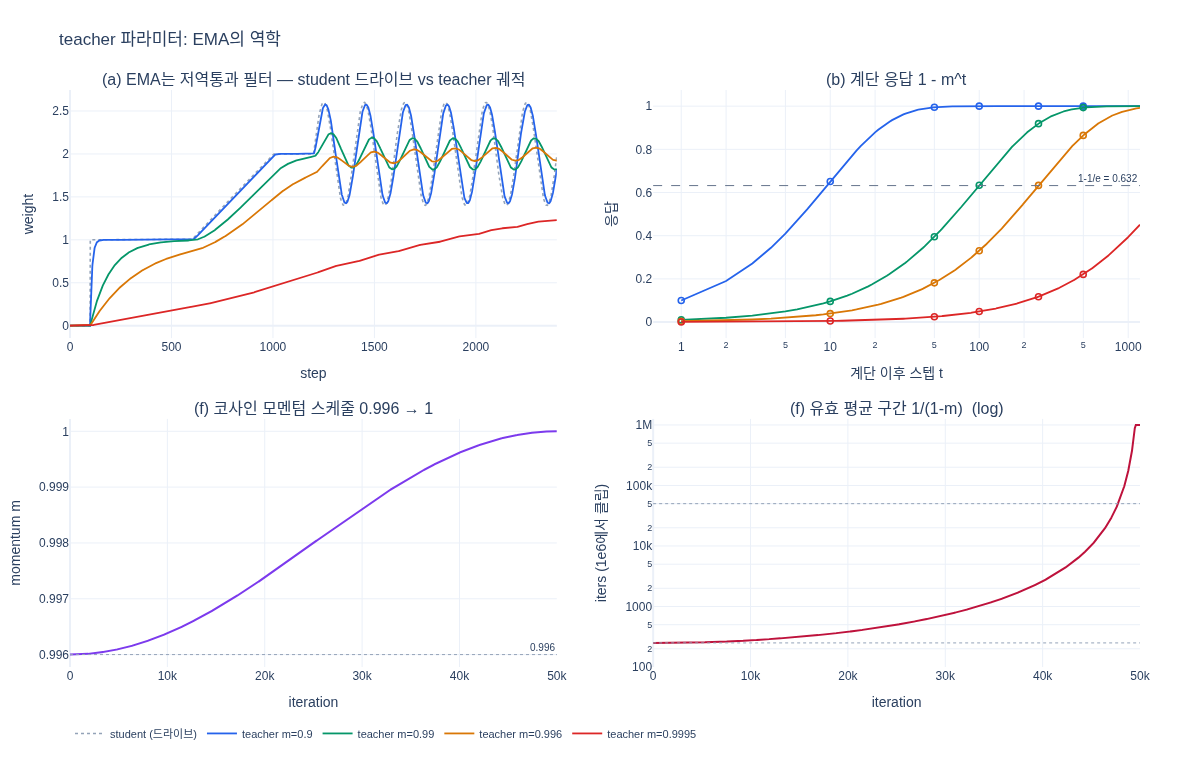

In [10]:
COLORS = ["#2563eb", "#059669", "#d97706", "#dc2626"]

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "(a) EMA는 저역통과 필터 — student 드라이브 vs teacher 궤적",
        "(b) 계단 응답 1 - m^t",
        "(f) 코사인 모멘텀 스케줄 0.996 → 1",
        "(f) 유효 평균 구간 1/(1-m)  (log)",
    ),
    horizontal_spacing=0.09, vertical_spacing=0.14,
)

# (a)
fig.add_trace(go.Scatter(y=s_ref, name="student (드라이브)", mode="lines",
                         line=dict(color="#94a3b8", width=1.6, dash="dot")), row=1, col=1)
for c, m in zip(COLORS, MOMENTA):
    fig.add_trace(go.Scatter(y=traj[m][1], name=f"teacher m={m}", mode="lines",
                             line=dict(color=c, width=1.8)), row=1, col=1)

# (b)
tt = np.arange(1, 1201)
for c, m in zip(COLORS, MOMENTA):
    fig.add_trace(go.Scatter(x=tt, y=1 - m**tt, name=f"1-m^t, m={m}", mode="lines",
                             line=dict(color=c, width=1.8), showlegend=False), row=1, col=2)
    seg = traj[m][1][100:600]
    ms = np.array([1, 10, 50, 100, 250, 499])
    fig.add_trace(go.Scatter(x=ms, y=seg[ms - 1], mode="markers", name=f"측정 m={m}",
                             marker=dict(color=c, size=6, symbol="circle-open", line=dict(width=1.6)),
                             showlegend=False), row=1, col=2)
fig.add_hline(y=1 - 1 / math.e, line=dict(color="#64748b", width=1, dash="dash"),
              annotation_text="1-1/e = 0.632", annotation_font_size=10, row=1, col=2)

# (f) schedule
it_ax = np.arange(len(mom))
fig.add_trace(go.Scatter(x=it_ax, y=mom, name="m(it)", mode="lines",
                         line=dict(color="#7c3aed", width=2), showlegend=False), row=2, col=1)
fig.add_hline(y=0.996, line=dict(color="#94a3b8", width=1, dash="dot"),
              annotation_text="0.996", annotation_font_size=10, row=2, col=1)

# (f) window — 끝에서 1/(1-m)이 1e12까지 발산하므로 1e6에서 클립해서 그린다
window_plot = np.clip(window, None, 1e6)
fig.add_trace(go.Scatter(x=it_ax, y=window_plot, name="1/(1-m)", mode="lines",
                         line=dict(color="#be123c", width=2), showlegend=False), row=2, col=2)
for yv, lab in [(250, "250 (m=0.996 시작)"), (len(mom), "전체 학습 길이 50k")]:
    fig.add_hline(y=yv, line=dict(color="#94a3b8", width=1, dash="dot"),
                  annotation_text=lab, annotation_font_size=10,
                  annotation_position="top left", row=2, col=2)

fig.update_xaxes(title_text="step", row=1, col=1)
fig.update_yaxes(title_text="weight", row=1, col=1)
fig.update_xaxes(title_text="계단 이후 스텝 t", type="log", row=1, col=2)
fig.update_yaxes(title_text="응답", row=1, col=2)
fig.update_xaxes(title_text="iteration", row=2, col=1)
fig.update_yaxes(title_text="momentum m", row=2, col=1)
fig.update_xaxes(title_text="iteration", row=2, col=2)
fig.update_yaxes(title_text="iters (1e6에서 클립)", type="log", range=[2, 6.1], row=2, col=2)

fig.update_layout(
    height=760, width=1180, template="plotly_white",
    title_text="teacher 파라미터: EMA의 역학",
    legend=dict(orientation="h", y=-0.09, x=0.0, font=dict(size=11)),
    margin=dict(t=90, b=90, l=70, r=40),
    font=dict(size=12),
)

import pathlib

out = pathlib.Path(__file__).parent / "expy.png" if "__file__" in dir() else pathlib.Path("expy.png")
fig.write_image(str(out), scale=2)
print("saved:", out)
_show(fig)

## 정리

| 실수 | 증상 | 왜 |
|---|---|---|
| `pt = pt * m + ...` | teacher가 영원히 초기값. 에러 없음 | 지역변수 재할당, 모듈의 `_parameters`는 그대로 |
| `no_grad` / `.data` 누락 | teacher가 non-leaf가 되고 gradient가 student로 역류, 메모리 누수 | `(1-m)*ps`가 그래프를 만들고 in-place로 전파 |
| EMA를 `opt.step()` 앞에 | teacher가 정확히 1스텝 뒤처짐 | 갱신 전 student를 평균 |
| `requires_grad_(False)` 누락 | optimizer가 teacher까지 학습, `.grad` 버퍼 메모리 낭비 | `get_params_groups`가 `requires_grad`로 거른다 |